In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import squigglepy as sq

from metr import fit_metr, load_metr_data

In [2]:
df = load_metr_data("data/benchmark_results_1_1.yaml", sota_only=True)
fit = fit_metr(df)

print(
    f"h50 fit: log(h) = {fit.intercept_50:.4f} + {fit.slope_50:.5f} * t  "
    f"(R² = {fit.r_squared_50:.3f})"
)
print(
    f"h80 fit: log(h) = {fit.intercept_80:.4f} + {fit.slope_80:.5f} * t  "
    f"(R² = {fit.r_squared_80:.3f})"
)
print(f"Doubling time: {fit.doubling_time_months:.2f} months")

h50 fit: log(h) = -4.1212 + 0.11422 * t  (R² = 0.941)
h80 fit: log(h) = -5.7015 + 0.11255 * t  (R² = 0.940)
Doubling time: 6.07 months


In [3]:
years = range(fit.base_date.year, 2038)
dates = [date(y, 1, 1) for y in years]
t_months = [(d - fit.base_date).days / 30.44 for d in dates]
n_samples = 500

# h50 ceiling options (set to None for exponential, or a value/distribution for logistic)
# ceiling = None  # exponential (unbounded)
# ceiling = 30 * 24 * 60  # fixed: 1 month
ceiling = sq.lognorm(df["p50_horizon"].max(), 30 * 24 * 60) @ n_samples

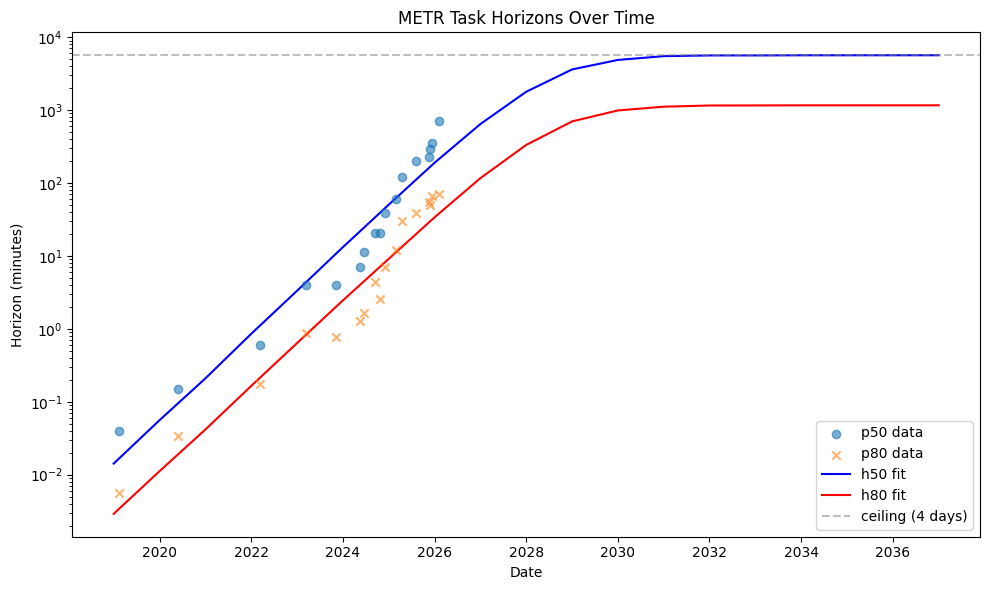

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Data points
ax.scatter(df["release_date"], df["p50_horizon"], alpha=0.6, label="p50 data", zorder=3)
ax.scatter(df["release_date"], df["p80_horizon"], alpha=0.6, label="p80 data", zorder=3, marker="x")

# Sample horizons at each date
h50_samples = np.array([fit.sample_horizons(t, n=n_samples, ceiling=ceiling)[0] for t in t_months])
h80_samples = np.array([fit.sample_horizons(t, n=n_samples, ceiling=ceiling)[1] for t in t_months])

h50_median = np.median(h50_samples, axis=1)
h80_median = np.median(h80_samples, axis=1)

ax.plot(dates, h50_median, "b-", label="h50 fit")
ax.plot(dates, h80_median, "r-", label="h80 fit")

# Show ceiling if set
if ceiling is not None:
    ceil_val = ceiling if isinstance(ceiling, (int, float)) else np.median(ceiling)
    ax.axhline(
        y=ceil_val,
        color="gray",
        linestyle="--",
        alpha=0.5,
        label=f"ceiling ({ceil_val / 60 / 24:.0f} days)",
    )

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Horizon (minutes)")
ax.set_title("METR Task Horizons Over Time")
ax.legend()
plt.tight_layout()
plt.show()

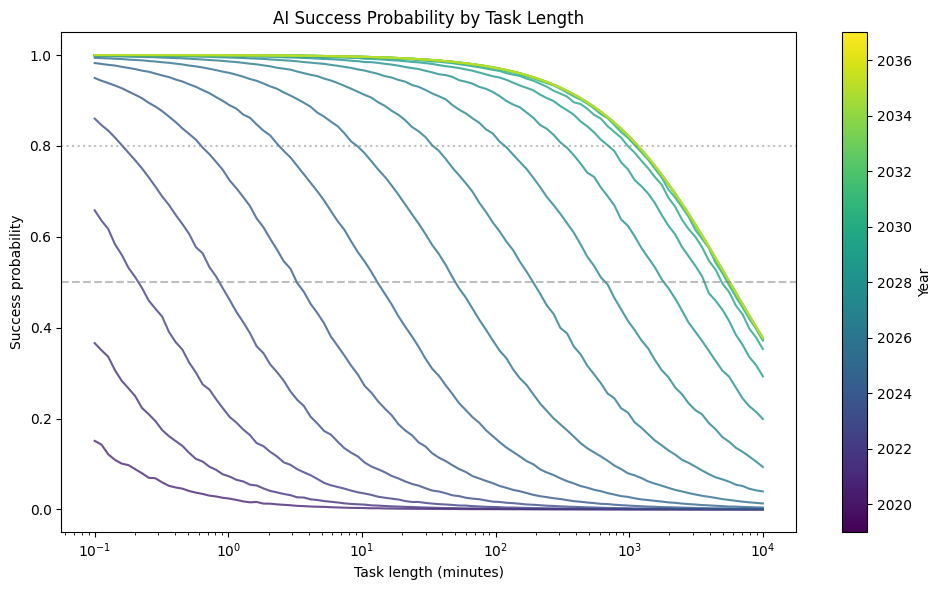

In [5]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 6))

task_range_min = np.logspace(-1, 4, 100)  # 0.1 min to 10,000 min

# Color gradient from light to dark
colors = cm.viridis(np.linspace(0.1, 0.9, len(years)))

for i, year in enumerate(years):
    d = date(year, 1, 1)
    t = (d - fit.base_date).days / 30.44

    # Median success probability at each task length
    probs = np.array(
        [
            np.median(fit.success_probability(task, t, n=n_samples, ceiling=ceiling))
            for task in task_range_min
        ]
    )
    ax.plot(task_range_min, probs, color=colors[i], alpha=0.8)

ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50%")
ax.axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="80%")
ax.set_xscale("log")
ax.set_xlabel("Task length (minutes)")
ax.set_ylabel("Success probability")
ax.set_title("AI Success Probability by Task Length")

# Add colorbar for years
sm = cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(min(years), max(years)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Year")

plt.tight_layout()
plt.show()

In [6]:
sw_task_distribution = sq.lognorm(10, 480)  # 90% CI: 10 min to 8 hr

n_tasks = 100000
task_durations = sw_task_distribution @ n_tasks
total_volume = np.sum(task_durations)

rows = []
for d, t in zip(dates, t_months):
    # Sample horizons once per date
    h50, h80 = fit.sample_horizons(t, n=n_samples, ceiling=ceiling)
    k = np.log(0.25) / np.log(h80 / h50)

    for i in range(n_samples):
        # Compute expected automated volume using success probability curve
        # Numerically stable calculation
        log_ratio = k[i] * np.log(task_durations / h50[i])
        log_ratio = np.clip(log_ratio, -50, 50)
        probs = 1 / (1 + np.exp(log_ratio))
        automated_volume = np.sum(task_durations * probs)
        frac_automated = automated_volume / total_volume
        speedup = 1 / (1 - frac_automated)

        rows.append(
            {
                "date": d,
                "h50": h50[i],
                "h80": h80[i],
                "k": k[i],
                "frac_automated": frac_automated,
                "speedup": speedup,
            }
        )

results = pd.DataFrame(rows)

# Summarize by year
summary = (
    results.groupby("date")
    .agg(
        h50_median=("h50", "median"),
        h80_median=("h80", "median"),
        k_median=("k", "median"),
        frac_automated_median=("frac_automated", "median"),
        speedup_median=("speedup", "median"),
        speedup_p5=("speedup", lambda x: np.percentile(x, 5)),
        speedup_p95=("speedup", lambda x: np.percentile(x, 95)),
    )
    .reset_index()
)

print(summary.to_string(index=False))

      date  h50_median  h80_median  k_median  frac_automated_median  speedup_median  speedup_p5  speedup_p95
2019-01-01    0.014341    0.003002  0.874411               0.000295        1.000295    1.000037     1.001421
2020-01-01    0.054782    0.011137  0.861224               0.001104        1.001106    1.000215     1.003270
2021-01-01    0.208701    0.041123  0.856780               0.003574        1.003587    1.001223     1.008208
2022-01-01    0.826792    0.159842  0.846536               0.012034        1.012180    1.006475     1.021162
2023-01-01    3.296950    0.618579  0.835618               0.036757        1.038159    1.024245     1.056700
2024-01-01   12.797748    2.398641  0.826454               0.101316        1.112738    1.086671     1.150093
2025-01-01   50.905958    9.233585  0.815637               0.240589        1.316810    1.246721     1.386713
2026-01-01  187.840398   33.655657  0.813258               0.438332        1.780412    1.589761     2.012996
2027-01-01  651.282

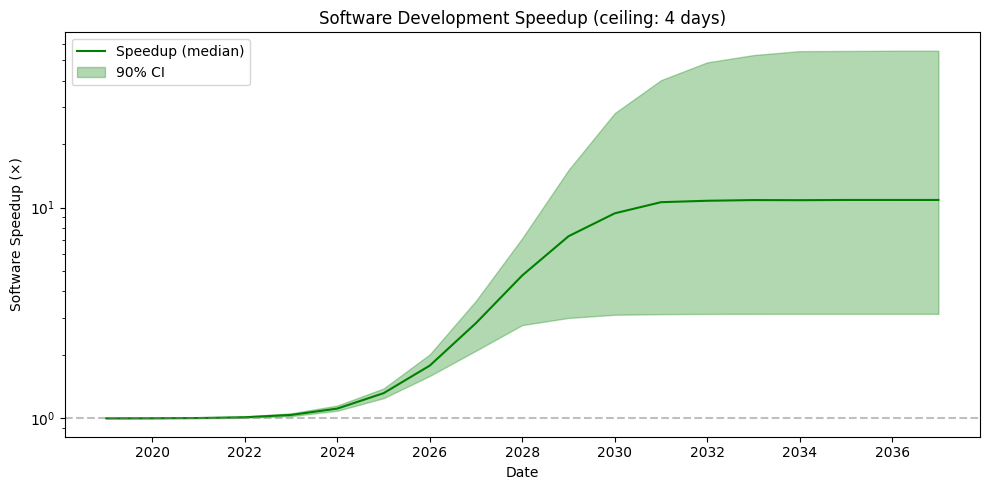

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(summary["date"], summary["speedup_median"], "g-", label="Speedup (median)")
ax.fill_between(
    summary["date"],
    summary["speedup_p5"],
    summary["speedup_p95"],
    alpha=0.3,
    color="green",
    label="90% CI",
)
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Software Speedup (×)")

title = "Software Development Speedup"
if ceiling is not None:
    ceil_val = ceiling if isinstance(ceiling, (int, float)) else np.median(ceiling)
    title += f" (ceiling: {ceil_val / 60 / 24:.0f} days)"
ax.set_title(title)

ax.legend(loc="upper left")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()